# 📘 Task 1: Text Classification (Age Group Prediction)

In [2]:
# Step 1: Import libraries
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Step 2: Load the dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Keep only relevant columns
df = df[['title', 'description', 'age']]

# Drop duplicates and blanks
df = df.drop_duplicates(subset="title").dropna(subset=["description"])
df.head()


,title,description,age
0,A TRICK TRIKE,Little Ross was sad. He didnÃ¢Â€Â™t have a nic...,Age 2-9
1,ABE THE SERVICE DOG,Abe was a real Service Dog who dedicated his l...,Age 2-9
2,BUBBLE FUN,"When the last bubble popped, he was gone but a...",Age 2-9
3,CAPTAIN FANTASTIC,Dr. ZobÃ¢Â€Â™s evil plans had failed once aga...,Age 2-9
4,DO YOU WONDER WHY BUGS ARE GOOD?,Those little beauties have inspired so many st...,Age 2-9


In [4]:
# Step 3: Create Age Groups (Toddler, Middle, Teen)

def extract_age_bucket(age_str):
    if pd.isna(age_str):
        return "Unknown"
    nums = re.findall(r'\d+', str(age_str))
    if not nums:
        return "Unknown"
    age_val = int(nums[0])  # take first numeric age
    if age_val <= 5:
        return "Toddler"
    elif age_val <= 12:
        return "Middle"
    else:
        return "Teen"

df['age_group'] = df['age'].apply(extract_age_bucket)

# Show distribution
df['age_group'].value_counts()


age_group
Middle     213
Toddler    193
Teen        22
Unknown      1
Name: count, dtype: int64

In [5]:
# Step 4: Prepare Data for Classification

# Drop unknowns
df_class = df[df['age_group'] != "Unknown"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_class['description'], df_class['age_group'],
    test_size=0.2, random_state=42, stratify=df_class['age_group']
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 342
Testing samples: 86


In [6]:
# Step 5: TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Train shape: (342, 5000)
Test shape: (86, 5000)


In [7]:
# Step 6: Train Logistic Regression Model
clf = LogisticRegression(max_iter=200, class_weight="balanced", solver="liblinear")
clf.fit(X_train_tfidf, y_train)

# Predictions
y_pred = clf.predict(X_test_tfidf)


Accuracy: 0.8255813953488372

Classification Report:
               precision    recall  f1-score   support

      Middle       0.79      0.88      0.84        43
        Teen       0.00      0.00      0.00         4
     Toddler       0.87      0.85      0.86        39

    accuracy                           0.83        86
   macro avg       0.55      0.58      0.56        86
weighted avg       0.79      0.83      0.81        86



C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

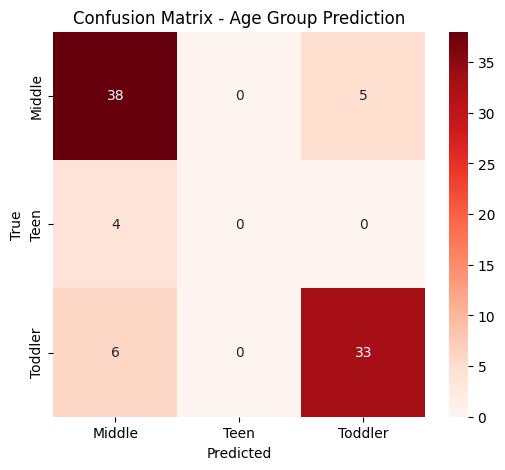

In [8]:
# Step 7: Evaluation

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Age Group Prediction")
plt.show()


In [9]:
# Step 8: Example Predictions
examples = X_test.sample(5, random_state=42)
for text in examples:
    pred = clf.predict(vectorizer.transform([text]))[0]
    print(f"\nStory: {text[:100]}...")
    print(f"Predicted Age Group: {pred}")



Story: A multicultural book showing babies engaged in many activities, such as playing in the mud, being in...
Predicted Age Group: Toddler

Story: King Arthur pulled the sword from the stone, had a Round Table and went in search of the Holy Grail....
Predicted Age Group: Middle

Story: Inside the little house live the Ingalls family: Ma, Pa, Mary, Laura and baby Carrie. Outside the li...
Predicted Age Group: Toddler

Story: Young Tilly is delighted when a polar bear clambers through her bedroom window one night and snuggle...
Predicted Age Group: Toddler

Story: Nearly forty years after its original appearance, it is shameful that ForemanÃ¢Â€Â™s innovative clas...
Predicted Age Group: Middle


# Task 2: Topic Modeling & Story Themes

In [10]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df = pd.read_excel("childrenstories_dataset.xlsx")  

# Clean descriptions
df['description'] = df['Description'].astype(str).str.lower()

In [11]:
# Step 1: Convert to document-term matrix
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['description'])


In [12]:
# Step 2: Apply LDA for Topic Modeling
n_topics = 5  # you can change to 6-10 to see more themes
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

# Get top words per topic
words = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic #{idx+1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda, words)



Topic #1:
book, children, story, new, young, world, life, readers, little, illustrations

Topic #2:
book, children, story, illustrations, father, love, classic, life, christmas, home

Topic #3:
book, new, story, children, school, time, life, way, calvin, little

Topic #4:
story, life, book, children, old, new, world, young, illustrations, little

Topic #5:
book, little, story, children, day, friends, young, family, life, time


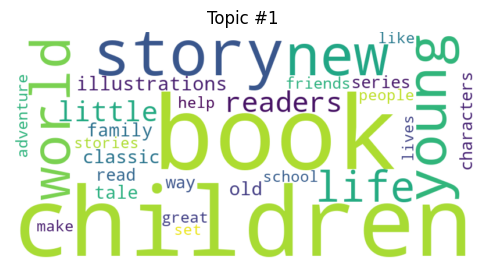

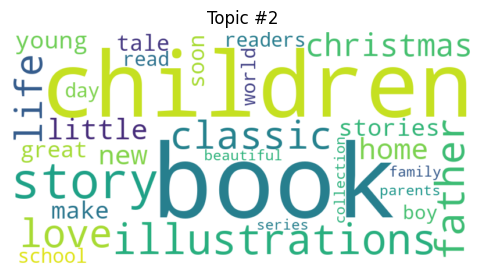

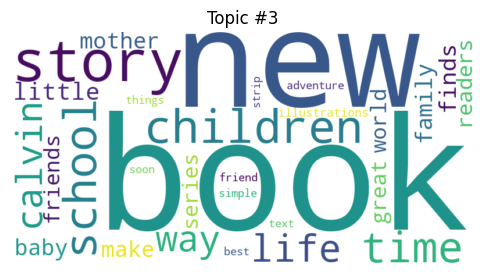

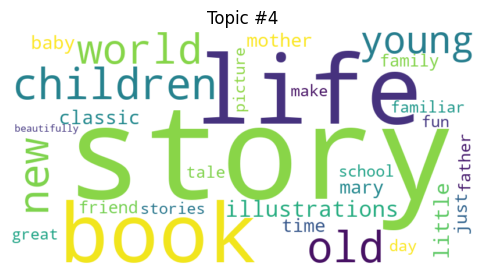

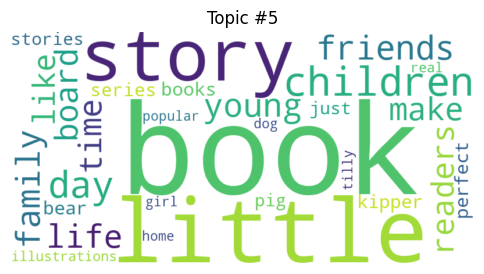

In [13]:
# Step 3: Visualize topics with WordClouds
for idx, topic in enumerate(lda.components_):
    plt.figure(figsize=(6, 4))
    wordcloud = WordCloud(width=800, height=400, background_color="white")
    wordcloud = wordcloud.generate_from_frequencies(
        {words[i]: topic[i] for i in topic.argsort()[:-30:-1]}
    )
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic #{idx+1}")
    plt.show()


# Task 3: Sentiment & Emotion Analysis

In [14]:
!pip install vaderSentiment


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [16]:
!pip install textblob


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
from textblob import TextBlob

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Check column names
print(df.columns)

# Choose the column with story descriptions (adjust if it's 'Desc' instead of 'description')
text_col = 'description' if 'description' in df.columns else 'Description'

# Sentiment function
def get_sentiment_textblob(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0.05:
        return "Positive"
    elif analysis.sentiment.polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df['sentiment'] = df[text_col].apply(get_sentiment_textblob)

# Show sample results
df[[text_col, 'sentiment']].head(10)


Index(['Title', 'Description', 'Age'], dtype='object')


,Description,sentiment
0,Little Ross was sad. He didnÃ¢Â€Â™t have a nic...,Neutral
1,Abe was a real Service Dog who dedicated his l...,Positive
2,"When the last bubble popped, he was gone but a...",Neutral
3,Dr. ZobÃ¢Â€Â™s evil plans had failed once aga...,Neutral
4,Those little beauties have inspired so many st...,Positive
5,Love shines through this great illustrated kid...,Positive
6,"In this classic tale, Dylan learns to make fri...",Positive
7,Read this warm tale of camaraderie and affecti...,Positive
8,HeÃ¢Â€Â™s got swag. He wears a tux. HeÃ¢Â€Â™s ...,Positive
9,When Jimmy and Tammy bring home an unusual pet...,Positive


C:\Users\HP\AppData\Local\Temp\ipykernel_15852\739572113.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


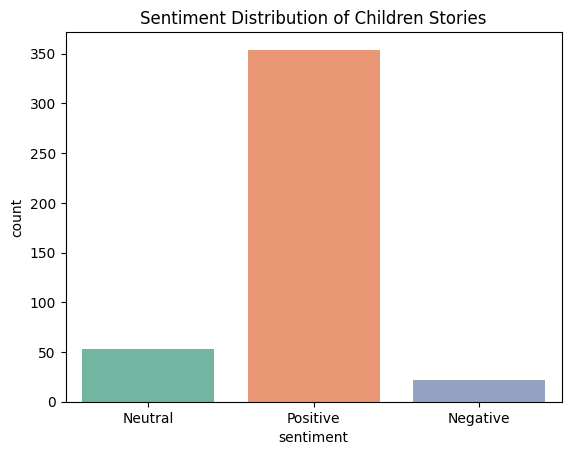

In [18]:
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Sentiment Distribution of Children Stories")
plt.show()


In [19]:
# Simple keyword-to-emotion mapping
emotion_map = {
    "happy": "Joy", "joy": "Joy", "smile": "Joy", "fun": "Joy", "play": "Joy",
    "sad": "Sadness", "cry": "Sadness", "tears": "Sadness",
    "scary": "Fear", "fear": "Fear", "dark": "Fear", "monster": "Fear",
    "friend": "Trust", "love": "Trust", "help": "Trust", "family": "Trust",
    "angry": "Anger", "mad": "Anger", "fight": "Anger",
    "surprise": "Surprise", "suddenly": "Surprise",
    "gross": "Disgust", "yuck": "Disgust",
    "hope": "Anticipation", "dream": "Anticipation", "magic": "Anticipation"
}

def detect_emotion(text):
    text = str(text).lower()
    for word, emo in emotion_map.items():
        if word in text:
            return emo
    return "Neutral"

df['emotion'] = df[text_col].apply(detect_emotion)

# Show sample results
df[[text_col, 'sentiment', 'emotion']].head(10)


,Description,sentiment,emotion
0,Little Ross was sad. He didnÃ¢Â€Â™t have a nic...,Neutral,Sadness
1,Abe was a real Service Dog who dedicated his l...,Positive,Trust
2,"When the last bubble popped, he was gone but a...",Neutral,Neutral
3,Dr. ZobÃ¢Â€Â™s evil plans had failed once aga...,Neutral,Neutral
4,Those little beauties have inspired so many st...,Positive,Neutral
5,Love shines through this great illustrated kid...,Positive,Joy
6,"In this classic tale, Dylan learns to make fri...",Positive,Trust
7,Read this warm tale of camaraderie and affecti...,Positive,Neutral
8,HeÃ¢Â€Â™s got swag. He wears a tux. HeÃ¢Â€Â™s ...,Positive,Neutral
9,When Jimmy and Tammy bring home an unusual pet...,Positive,Joy


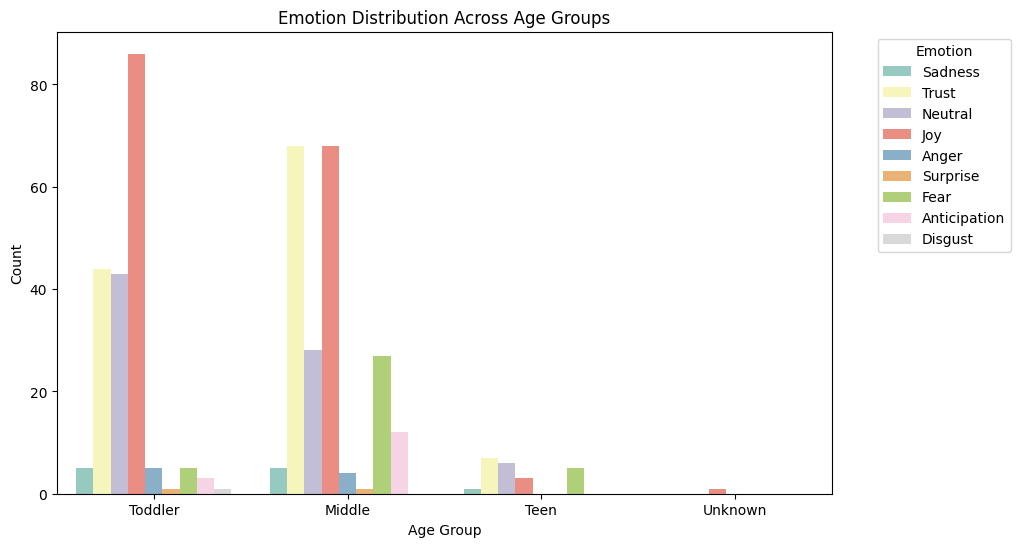

In [20]:
import re
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Create Age Buckets if not already there ---
def extract_age_bucket(age_str):
    if pd.isna(age_str):
        return "Unknown"
    nums = re.findall(r'\d+', str(age_str))
    if not nums:
        return "Unknown"
    age_val = int(nums[0])  # take first numeric age
    if age_val <= 5:
        return "Toddler"
    elif age_val <= 12:
        return "Middle"
    else:
        return "Teen"

if 'age_group' not in df.columns:
    df['age_group'] = df['Age'].apply(extract_age_bucket)

# --- Step 2: Plot emotion distribution per age group ---
plt.figure(figsize=(10,6))
sns.countplot(x="age_group", hue="emotion", data=df, palette="Set3")
plt.title("Emotion Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


emotion       Anger  Anticipation   Disgust       Fear         Joy    Neutral  \
age_group                                                                       
Middle     1.877934      5.633803  0.000000  12.676056   31.924883  13.145540   
Teen       0.000000      0.000000  0.000000  22.727273   13.636364  27.272727   
Toddler    2.590674      1.554404  0.518135   2.590674   44.559585  22.279793   
Unknown    0.000000      0.000000  0.000000   0.000000  100.000000   0.000000   

emotion     Sadness  Surprise      Trust  
age_group                                 
Middle     2.347418  0.469484  31.924883  
Teen       4.545455  0.000000  31.818182  
Toddler    2.590674  0.518135  22.797927  
Unknown    0.000000  0.000000   0.000000  


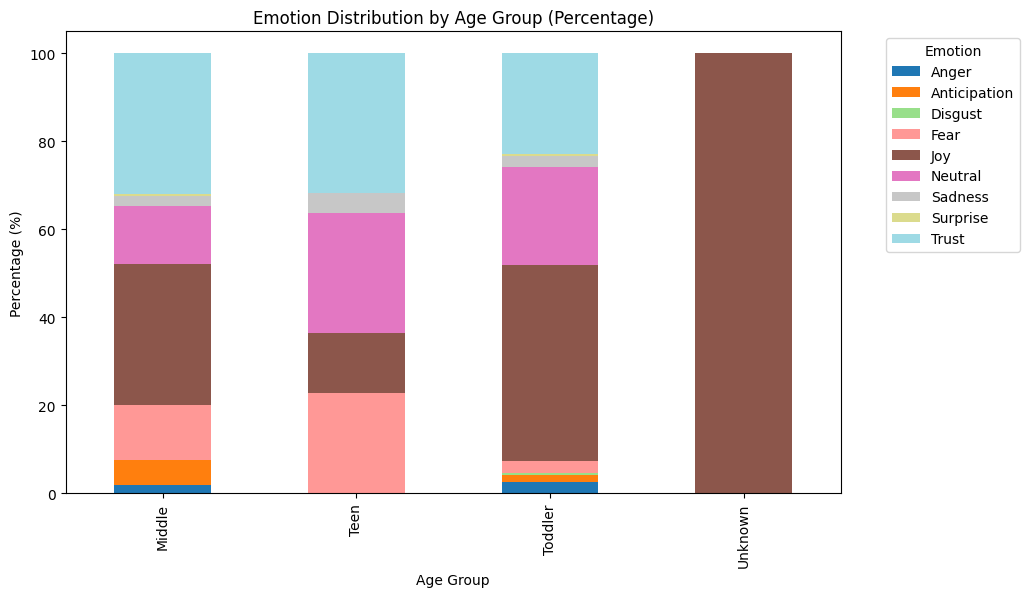

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Cross-tab of emotions per age group
emotion_age_counts = pd.crosstab(df['age_group'], df['emotion'])

# Step 2: Convert counts to percentages
emotion_age_pct = emotion_age_counts.div(emotion_age_counts.sum(axis=1), axis=0) * 100

print(emotion_age_pct.head())

# Step 3: Plot stacked bar chart (percentages)
emotion_age_pct.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")
plt.title("Emotion Distribution by Age Group (Percentage)")
plt.ylabel("Percentage (%)")
plt.xlabel("Age Group")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


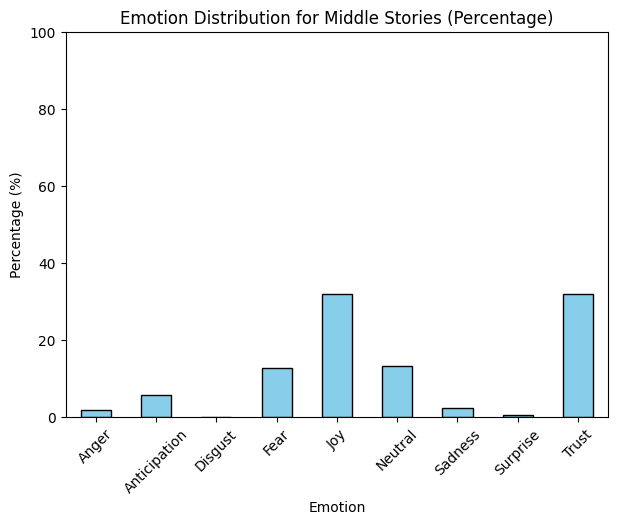

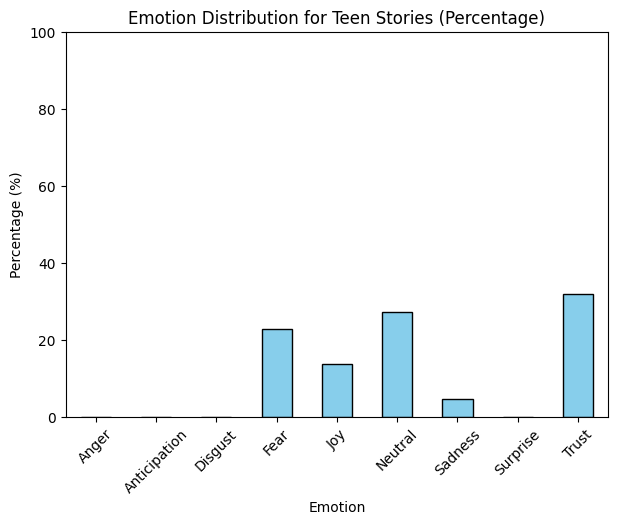

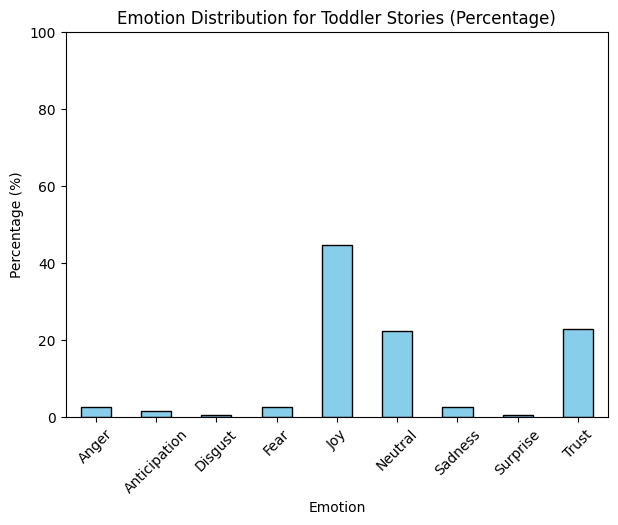

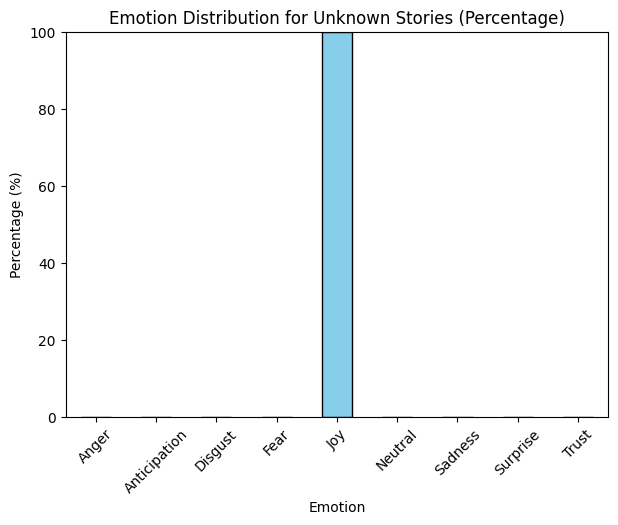

In [22]:
# Step 1: Calculate emotion percentages per age group
emotion_age_counts = pd.crosstab(df['age_group'], df['emotion'])
emotion_age_pct = emotion_age_counts.div(emotion_age_counts.sum(axis=1), axis=0) * 100

# Step 2: Plot separate graphs for each age group
for age_group in emotion_age_pct.index:
    plt.figure(figsize=(7,5))
    emotion_age_pct.loc[age_group].plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Emotion Distribution for {age_group} Stories (Percentage)")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Emotion")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.show()


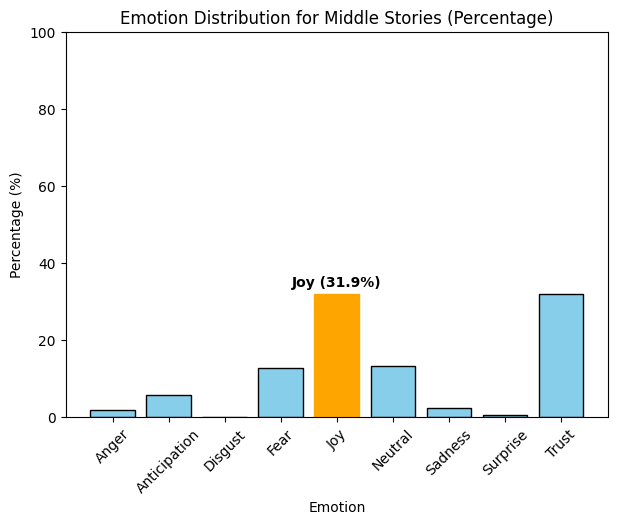

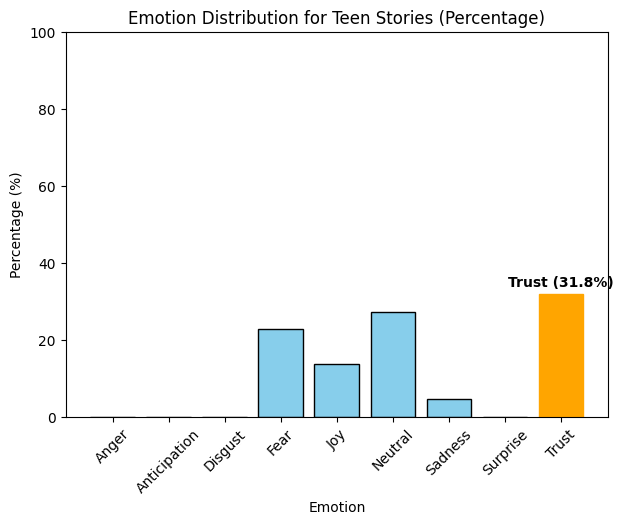

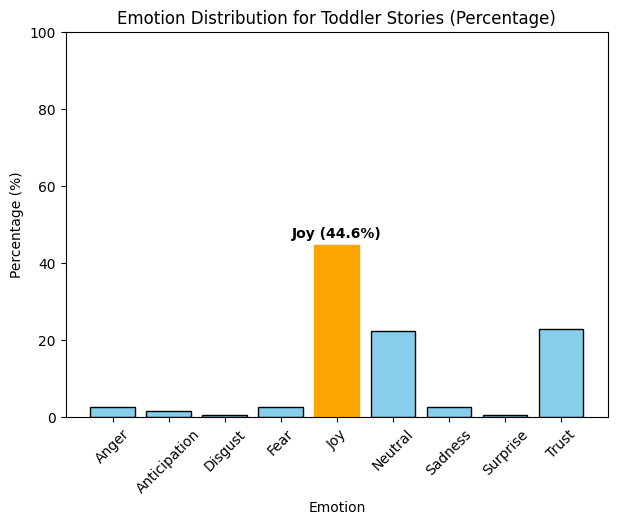

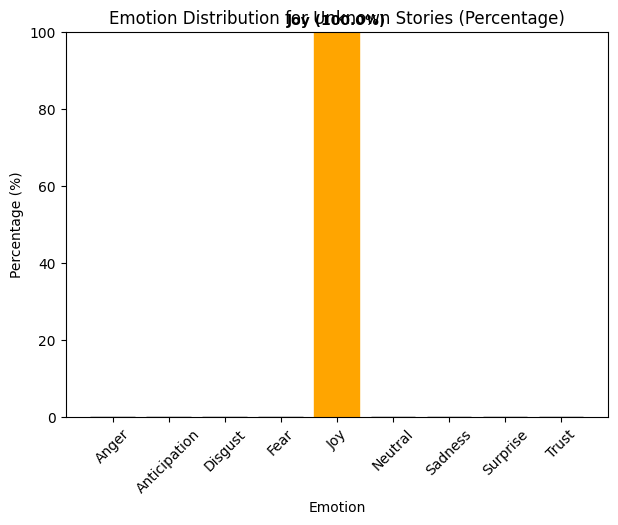

In [23]:
# Step 1: Calculate emotion percentages per age group
emotion_age_counts = pd.crosstab(df['age_group'], df['emotion'])
emotion_age_pct = emotion_age_counts.div(emotion_age_counts.sum(axis=1), axis=0) * 100

# Step 2: Plot separate graphs for each age group with top emotion labeled
for age_group in emotion_age_pct.index:
    plt.figure(figsize=(7,5))
    bars = plt.bar(emotion_age_pct.loc[age_group].index,
                   emotion_age_pct.loc[age_group].values,
                   color='skyblue', edgecolor='black')

    # Find dominant emotion
    top_emotion = emotion_age_pct.loc[age_group].idxmax()
    top_value = emotion_age_pct.loc[age_group].max()

    # Highlight top bar
    for bar, emo in zip(bars, emotion_age_pct.loc[age_group].index):
        if emo == top_emotion:
            bar.set_color("orange")   # highlight top emotion
            plt.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 2,
                     f"{top_emotion} ({top_value:.1f}%)",
                     ha='center', fontsize=10, fontweight='bold')

    # Formatting
    plt.title(f"Emotion Distribution for {age_group} Stories (Percentage)")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Emotion")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.show()


# Task 4: Story Recommendation System.

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Detect description column
text_col = 'description' if 'description' in df.columns else 'Description'
title_col = 'title' if 'title' in df.columns else 'Title'

# Step 1: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df[text_col].astype(str))

# Step 2: Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [25]:
def recommend_story(title, top_n=5):
    # Find index of the story
    if title not in df[title_col].values:
        return f"Story '{title}' not found in dataset."
    
    idx = df[df[title_col] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity (excluding itself)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    # Get recommended story titles
    recommended = [df.iloc[i][title_col] for i, _ in sim_scores]
    
    return recommended


In [26]:
# Pick a story title from your dataset
sample_title = df[title_col].iloc[0]
print("Input Story:", sample_title)

print("\nRecommended Stories:")
print(recommend_story(sample_title, top_n=5))


Input Story:  A TRICK TRIKE

Recommended Stories:
['Lost and Found', 'I Want My Potty!', ' SUNNY MEADOWS WOODLAND SCHOOL', 'The Merchant of Venice: A Shakespeare Story', 'My Dad is Brilliant']


# Task 5: Diversity & Representation Analysis.

In [27]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
nlp = spacy.load("en_core_web_sm")

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Detect description column
text_col = 'description' if 'description' in df.columns else 'Description'

# Load SpaCy model (make sure to install: !python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

# Apply NER to story descriptions
def extract_entities(text):
    doc = nlp(str(text))
    people = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    places = [ent.text for ent in doc.ents if ent.label_ in ["GPE", "LOC"]]
    return people, places

df['entities'] = df[text_col].apply(extract_entities)
df[['people', 'places']] = pd.DataFrame(df['entities'].tolist(), index=df.index)


OSError: [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

In [ ]:
#Step 2: Handle Animals (Custom Keyword List)

# Define common animals (expand as needed)
animal_list = ["dog", "cat", "rabbit", "lion", "tiger", "bear", "mouse", "elephant", "giraffe", "monkey"]

def extract_animals(text):
    text = str(text).lower()
    return [animal for animal in animal_list if animal in text]

df['animals'] = df[text_col].apply(extract_animals)


In [ ]:
# Step 3: Analyze Frequencies
from collections import Counter

# Flatten lists
all_people = [p for sublist in df['people'] for p in sublist]
all_places = [p for sublist in df['places'] for p in sublist]
all_animals = [a for sublist in df['animals'] for a in sublist]

# Count
people_counts = Counter(all_people).most_common(10)
places_counts = Counter(all_places).most_common(10)
animals_counts = Counter(all_animals).most_common(10)

print("Top Characters:", people_counts)
print("Top Places:", places_counts)
print("Top Animals:", animals_counts)


In [ ]:
#Step 4: Visualize 
def plot_counts(counts, title):
    items, values = zip(*counts)
    plt.figure(figsize=(8,5))
    sns.barplot(x=list(items), y=list(values), palette="viridis")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_counts(people_counts, "Top Characters in Stories")
plot_counts(places_counts, "Top Places in Stories")
plot_counts(animals_counts, "Top Animals in Stories")


# Task 6: Clustering of Stories.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("C:/Users/madhu/OneDrive/Desktop/childrenstories_dataset.xlsx")

# Detect description column
text_col = 'description' if 'description' in df.columns else 'Description'
title_col = 'title' if 'title' in df.columns else 'Title'

# Step 1: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(df[text_col].astype(str))

# Step 2: KMeans Clustering
n_clusters = 5  # you can tune this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)


In [ ]:
#Step 3: Cluster Visualization (t-SNE)
# Reduce to 2D with t-SNE for plotting
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_embedded = tsne.fit_transform(X.toarray())

df['x'] = X_embedded[:,0]
df['y'] = X_embedded[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='x', y='y', hue='cluster', palette="tab10", data=df, legend="full")
plt.title("t-SNE Clustering of Children Stories")
plt.show()


In [ ]:
#Step 4: Inspect Sample Stories per Cluster
for c in range(n_clusters):
    print(f"\nCluster {c}:")
    sample_titles = df[df['cluster'] == c][title_col].head(5).tolist()
    print(sample_titles)


In [ ]:
####not mandatory###

import numpy as np

# Step 5: Get top keywords per cluster
def get_top_keywords_per_cluster(tfidf_matrix, labels, feature_names, n_terms=10):
    df_out = {}
    for cluster_num in np.unique(labels):
        # Average TF-IDF score for each word in this cluster
        cluster_docs = tfidf_matrix[labels == cluster_num]
        mean_tfidf = cluster_docs.mean(axis=0).A1  # average across rows
        top_indices = mean_tfidf.argsort()[-n_terms:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        df_out[cluster_num] = top_words
    return df_out

# Extract feature names
feature_names = vectorizer.get_feature_names_out()

# Get top words for each cluster
cluster_keywords = get_top_keywords_per_cluster(X, df['cluster'].values, feature_names, n_terms=10)

# Print cluster summaries
for cluster, keywords in cluster_keywords.items():
    print(f"\nCluster {cluster} keywords: {', '.join(keywords)}")


In [ ]:
# Step 1: Compute title length in words
df['title_length'] = df[title_col].astype(str).apply(lambda x: len(x.split()))

# Step 2: Define age groups (already done in previous tasks, but redo just in case)
def extract_age_bucket(age_str):
    if pd.isna(age_str):
        return "Unknown"
    nums = re.findall(r'\d+', str(age_str))
    if not nums:
        return "Unknown"
    age_val = int(nums[0])
    if age_val <= 5:
        return "Toddler"
    elif age_val <= 12:
        return "Middle"
    else:
        return "Teen"

df['age_group'] = df['Age'].apply(extract_age_bucket)

# Step 3: Plot separate histograms for each age group
for age_group in ["Toddler", "Middle", "Teen"]:
    subset = df[df['age_group'] == age_group]
    if len(subset) == 0:
        continue
    
    plt.figure(figsize=(7,5))
    sns.histplot(subset['title_length'], bins=6, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of Title Lengths - {age_group}")
    plt.xlabel("Title Length (words)")
    plt.ylabel("Count")
    plt.show()


In [ ]:
!pip install spacy


In [ ]:
from spacy.lang.en.stop_words import STOP_WORDS as stopwords


In [ ]:
# --- LDA Topic Modeling Section (Final Output like Lecture Slides) ---

import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from spacy.lang.en.stop_words import STOP_WORDS as stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis.sklearn
import pyLDAvis

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
df["text"] = df["text"].astype(str)

# Optional: split long text into smaller paragraphs
df["paragraphs"] = df["text"].map(lambda text: re.split(r'\.\s*\n', text))
paragraph_df = pd.DataFrame([
    {"text": para}
    for paras in df["paragraphs"]
    for para in paras if para
])
print("Paragraph dataset shape:", paragraph_df.shape)

# --- Vectorize Text using CountVectorizer ---
count_vectorizer = CountVectorizer(stop_words=stopwords, min_df=5, max_df=0.7)
count_vectors = count_vectorizer.fit_transform(paragraph_df["text"])
print("Count Vector Shape:", count_vectors.shape)

# --- Run LDA ---
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda = lda_model.fit_transform(count_vectors)
H_lda = lda_model.components_

# --- Display Topics (top words) ---
def display_topics(model, features, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        total = topic.sum()
        top_indices = topic.argsort()[::-1]
        print(f"\nTopic {topic_idx:02d}:")
        for i in range(no_top_words):
            print(f"  {features[top_indices[i]]} ({topic[top_indices[i]]*100.0/total:.2f}%)")

display_topics(lda_model, count_vectorizer.get_feature_names_out())

# --- pyLDAvis Visualization ---
lda_display = pyLDAvis.sklearn.prepare(
    lda_model, count_vectors, count_vectorizer, sort_topics=False
)
pyLDAvis.display(lda_display)

# --- WordClouds for Topics ---
def wordcloud_topics(model, features, no_top_words=40):
    for topic_idx, topic in enumerate(model.components_):
        word_freq = {features[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        plt.figure(figsize=(10,8))
        plt.imshow(wc.generate_from_frequencies(word_freq), interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_idx:02d}")
        plt.show()

wordcloud_topics(lda_model, count_vectorizer.get_feature_names_out())


In [ ]:
# --- LDA Topic Modeling Section (Final Output like Lecture Slides, Fixed pyLDAvis) ---

import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

# Use sklearn's built-in English stopwords
stopwords = text.ENGLISH_STOP_WORDS

# --- Load dataset ---
df = pd.read_excel("childrenstories_dataset.xlsx")
df["text"] = df["text"].astype(str)

# Optional: split long text into smaller paragraphs
df["paragraphs"] = df["text"].map(lambda text: re.split(r'\.\s*\n', text))
paragraph_df = pd.DataFrame([
    {"text": para}
    for paras in df["paragraphs"]
    for para in paras if para
])
print("Paragraph dataset shape:", paragraph_df.shape)

# --- Vectorize Text using CountVectorizer ---
count_vectorizer = CountVectorizer(stop_words=stopwords, min_df=5, max_df=0.7)
count_vectors = count_vectorizer.fit_transform(paragraph_df["text"])
print("Count Vector Shape:", count_vectors.shape)

# --- Run LDA ---
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda = lda_model.fit_transform(count_vectors)
H_lda = lda_model.components_

# --- Display Topics (Top Words) ---
def display_topics(model, features, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        total = topic.sum()
        top_indices = topic.argsort()[::-1]
        print(f"\nTopic {topic_idx:02d}:")
        for i in range(no_top_words):
            print(f"  {features[top_indices[i]]} ({topic[top_indices[i]]*100.0/total:.2f}%)")

display_topics(lda_model, count_vectorizer.get_feature_names_out())

# --- pyLDAvis Visualization ---
pyLDAvis.enable_notebook()
lda_display = pyLDAvis.lda_model.prepare(
    lda_model, count_vectors, count_vectorizer, sort_topics=False
)
lda_display

# --- WordClouds for Topics ---
def wordcloud_topics(model, features, no_top_words=40):
    for topic_idx, topic in enumerate(model.components_):
        word_freq = {features[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        plt.figure(figsize=(10,8))
        plt.imshow(wc.generate_from_frequencies(word_freq), interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_idx:02d}")
        plt.show()

wordcloud_topics(lda_model, count_vectorizer.get_feature_names_out())


In [ ]:
# --- LDA Topic Modeling Section (Auto-detects text column) ---

import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

# Use sklearn's built-in English stopwords
stopwords = text.ENGLISH_STOP_WORDS

# --- Load dataset ---
df = pd.read_excel("childrenstories_dataset.xlsx")

print("Columns in dataset:", list(df.columns))

# Auto-detect the column containing story text
possible_cols = ["text", "Text", "story", "Story", "description", "Description", "content", "Content"]
text_col = None
for c in possible_cols:
    if c in df.columns:
        text_col = c
        break

if text_col is None:
    raise ValueError("❌ No text column found! Please check your Excel file’s column names.")

print(f"Using column: {text_col}")

# Convert to string
df[text_col] = df[text_col].astype(str)

# --- Split long text into smaller paragraphs ---
df["paragraphs"] = df[text_col].map(lambda t: re.split(r'\.\s*\n', t))
paragraph_df = pd.DataFrame([
    {"text": para}
    for paras in df["paragraphs"]
    for para in paras if para
])
print("Paragraph dataset shape:", paragraph_df.shape)

# --- Vectorize Text using CountVectorizer ---
count_vectorizer = CountVectorizer(stop_words=stopwords, min_df=5, max_df=0.7)
count_vectors = count_vectorizer.fit_transform(paragraph_df["text"])
print("Count Vector Shape:", count_vectors.shape)

# --- Run LDA ---
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda = lda_model.fit_transform(count_vectors)
H_lda = lda_model.components_

# --- Display Topics (Top Words) ---
def display_topics(model, features, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        total = topic.sum()
        top_indices = topic.argsort()[::-1]
        print(f"\nTopic {topic_idx:02d}:")
        for i in range(no_top_words):
            print(f"  {features[top_indices[i]]} ({topic[top_indices[i]]*100.0/total:.2f}%)")

display_topics(lda_model, count_vectorizer.get_feature_names_out())

# --- pyLDAvis Visualization ---
pyLDAvis.enable_notebook()
lda_display = pyLDAvis.lda_model.prepare(
    lda_model, count_vectors, count_vectorizer, sort_topics=False
)
lda_display

# --- WordClouds for Topics ---
def wordcloud_topics(model, features, no_top_words=40):
    for topic_idx, topic in enumerate(model.components_):
        word_freq = {features[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        plt.figure(figsize=(10,8))
        plt.imshow(wc.generate_from_frequencies(word_freq), interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_idx:02d}")
        plt.show()

wordcloud_topics(lda_model, count_vectorizer.get_feature_names_out())


In [ ]:
# --- LDA Topic Modeling Section (Final Version, All Errors Fixed) ---

import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

# Convert stopwords set into a list
stopwords = list(text.ENGLISH_STOP_WORDS)

# --- Load dataset ---
df = pd.read_excel("childrenstories_dataset.xlsx")

print("Columns in dataset:", list(df.columns))

# Auto-detect the column containing story text
possible_cols = ["text", "Text", "story", "Story", "description", "Description", "content", "Content"]
text_col = None
for c in possible_cols:
    if c in df.columns:
        text_col = c
        break

if text_col is None:
    raise ValueError("❌ No text column found! Please check your Excel file’s column names.")

print(f"Using column: {text_col}")

# Convert to string
df[text_col] = df[text_col].astype(str)

# --- Split long text into smaller paragraphs ---
df["paragraphs"] = df[text_col].map(lambda t: re.split(r'\.\s*\n', t))
paragraph_df = pd.DataFrame([
    {"text": para}
    for paras in df["paragraphs"]
    for para in paras if para
])
print("Paragraph dataset shape:", paragraph_df.shape)

# --- Vectorize Text using CountVectorizer ---
count_vectorizer = CountVectorizer(stop_words=stopwords, min_df=5, max_df=0.7)
count_vectors = count_vectorizer.fit_transform(paragraph_df["text"])
print("Count Vector Shape:", count_vectors.shape)

# --- Run LDA ---
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda = lda_model.fit_transform(count_vectors)
H_lda = lda_model.components_

# --- Display Topics (Top Words) ---
def display_topics(model, features, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        total = topic.sum()
        top_indices = topic.argsort()[::-1]
        print(f"\nTopic {topic_idx:02d}:")
        for i in range(no_top_words):
            print(f"  {features[top_indices[i]]} ({topic[top_indices[i]]*100.0/total:.2f}%)")

display_topics(lda_model, count_vectorizer.get_feature_names_out())

# --- pyLDAvis Visualization ---
pyLDAvis.enable_notebook()
lda_display = pyLDAvis.lda_model.prepare(
    lda_model, count_vectors, count_vectorizer, sort_topics=False
)
lda_display

# --- WordClouds for Topics ---
def wordcloud_topics(model, features, no_top_words=40):
    for topic_idx, topic in enumerate(model.components_):
        word_freq = {features[i]: topic[i] for i in topic.argsort()[:-no_top_words - 1:-1]}
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        plt.figure(figsize=(10,8))
        plt.imshow(wc.generate_from_frequencies(word_freq), interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {topic_idx:02d}")
        plt.show()

wordcloud_topics(lda_model, count_vectorizer.get_feature_names_out())


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: Suppose you have a DataFrame "topic_over_time"
# Rows = years, Columns = topics, Values = % contribution of each topic
# For example:
# topic_over_time = pd.DataFrame({
#     "Year": [1970, 1980, 1990, 2000, 2010],
#     "Topic 1": [10, 20, 30, 25, 15],
#     "Topic 2": [30, 25, 20, 30, 35],
#     "Topic 3": [60, 55, 50, 45, 50]
# })

# Replace this with your actual topic proportions
# Ensure "Year" is the index
topic_over_time.set_index("Year", inplace=True)

# Plot stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(topic_over_time.index,
              topic_over_time.T,
              labels=topic_over_time.columns,
              alpha=0.8)

plt.legend(loc='upper right')
plt.title("Topic Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Topic Proportion (%)")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Assuming dataset has a column 'Story' (adjust name if different)
texts = df['Story'].astype(str).tolist()

# 2. Vectorize text
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(texts)

# 3. Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 5 topics
lda_output = lda.fit_transform(X)

# lda_output = topic proportions per document
topic_df = pd.DataFrame(lda_output, columns=[f"Topic {i+1}" for i in range(5)])

# 4. Add index as a "story order" for plotting
topic_df["Story"] = df.index

# 5. Plot stacked area chart
topic_df.set_index("Story", inplace=True)

plt.figure(figsize=(12,6))
plt.stackplot(topic_df.index,
              topic_df.T,
              labels=topic_df.columns,
              alpha=0.8)

plt.legend(loc='upper right')
plt.title("Topic Distribution Across Stories")
plt.xlabel("Story Index")
plt.ylabel("Topic Proportion")
plt.show()


In [ ]:
import pandas as pd

df = pd.read_excel("childrenstories_dataset.xlsx")
print(df.columns)
df.head()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Use the story descriptions for topic modeling
texts = df['Description'].astype(str).tolist()

# 2. Vectorize text
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(texts)

# 3. Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # adjust n_components for more/less topics
lda_output = lda.fit_transform(X)

# Convert topic distribution into DataFrame
topic_df = pd.DataFrame(lda_output, columns=[f"Topic {i+1}" for i in range(5)])

# 4. Add index as "Story Order"
topic_df["Story"] = df.index

# 5. Plot stacked area chart
topic_df.set_index("Story", inplace=True)

plt.figure(figsize=(12,6))
plt.stackplot(topic_df.index,
              topic_df.T,
              labels=topic_df.columns,
              alpha=0.8)

plt.legend(loc='upper right')
plt.title("Topic Distribution Across Children Stories")
plt.xlabel("Story Index")
plt.ylabel("Topic Proportion")
plt.show()


In [ ]:
!pip install nrclex


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import defaultdict

# 1. Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# 2. Download NRC Emotion Lexicon (only first time)
nltk.download('stopwords')
nltk.download('punkt')

# Load NRC Emotion Lexicon (you may need to download the file separately)
# For now, let's use a sample lexicon dictionary (simplified version)
# Full lexicon can be installed via: pip install nrclex
from nrclex import NRCLex

# 3. Get emotions for each story
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    # Convert to DataFrame-friendly dictionary
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# Normalize each row to proportions
emotion_df = emotion_df.div(emotion_df.sum(axis=1), axis=0)

# Add story index
emotion_df["Story"] = df.index
emotion_df.set_index("Story", inplace=True)

# 4. Plot stacked area chart
plt.figure(figsize=(30,10))
plt.stackplot(emotion_df.index,
              emotion_df.T,
              labels=emotion_df.columns,
              alpha=0.8)

plt.legend(loc='upper right')
plt.title("Emotion Distribution Across Children Stories")
plt.xlabel("Story Index")
plt.ylabel("Emotion Proportion")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# Extract emotions using NRCLex
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# Normalize proportions
emotion_df = emotion_df.div(emotion_df.sum(axis=1), axis=0)

# Add story index
emotion_df["Story"] = df["Title"]   # use Title for better labels
emotion_df.set_index("Story", inplace=True)

# Plot horizontal stacked bar chart
emotion_df.plot(kind="barh",
                stacked=True,
                figsize=(12,10),
                alpha=0.8,
                colormap="tab20")

plt.title("Emotion Distribution Across Children Stories")
plt.xlabel("Proportion")
plt.ylabel("Stories")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
           ncol=4, fontsize="small")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")

# Use story descriptions
texts = df['Description'].astype(str).tolist()

# Extract emotions for each story
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# Normalize to proportions
emotion_df = emotion_df.div(emotion_df.sum(axis=1), axis=0)

# Add story titles as index
emotion_df["Story"] = df["Title"]
emotion_df.set_index("Story", inplace=True)

# Horizontal stacked bar chart
plt.figure(figsize=(12,10))
emotion_df.plot(kind="barh",
                stacked=True,
                figsize=(20,10),
                alpha=0.85,
                colormap="tab20")

plt.title("Emotion Distribution Across Children Stories", fontsize=14, weight="bold")
plt.xlabel("Proportion", fontsize=12)
plt.ylabel("Stories", fontsize=12)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08),
           ncol=4, fontsize="small")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# Extract emotions for each story
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# --- Find Top 5 emotions across all stories ---
top5_emotions = emotion_df.sum().sort_values(ascending=False).head(5).index
emotion_df = emotion_df[top5_emotions]

# Normalize to proportions
emotion_df = emotion_df.div(emotion_df.sum(axis=1), axis=0)

# Add story titles as index
emotion_df["Story"] = df["Title"]
emotion_df.set_index("Story", inplace=True)

# --- Horizontal stacked bar chart with Top 5 Emotions ---
plt.figure(figsize=(12,10))
emotion_df.plot(kind="barh",
                stacked=True,
                figsize=(12,10),
                alpha=0.85,
                colormap="tab10")

plt.title("Top 5 Emotions Distribution Across Children Stories", fontsize=14, weight="bold")
plt.xlabel("Proportion", fontsize=12)
plt.ylabel("Stories", fontsize=12)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08),
           ncol=5, fontsize="small")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# Extract emotions for each story
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# --- Get Top 5 emotions overall ---
top5_emotions = emotion_df.sum().sort_values(ascending=False).head(5)

# Bubble chart
plt.figure(figsize=(8,8))
colors = plt.cm.Set2(range(len(top5_emotions)))

for i, (emotion, value) in enumerate(top5_emotions.items()):
    plt.scatter(i, 0, s=value*100, color=colors[i], alpha=0.7, edgecolors="black")
    plt.text(i, 0, emotion, ha="center", va="center", fontsize=12, weight="bold", color="black")

# Remove axes
plt.axis("off")
plt.title("Top 5 Emotions in Children Stories", fontsize=16, weight="bold")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# Extract emotions for each story
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

# Convert to DataFrame
emotion_df = pd.DataFrame(emotion_data).fillna(0)

# --- Get Top 5 emotions overall ---
top5_emotions = emotion_df.sum().sort_values(ascending=False).head(5)

# --- Bubble Chart (infographic style) ---
plt.figure(figsize=(10,6))
colors = plt.cm.Pastel1(range(len(top5_emotions)))

# Place bubbles evenly spaced across X axis
for i, (emotion, value) in enumerate(top5_emotions.items()):
    plt.scatter(i, 0, 
                s=value*200,   # scale bubble size
                color=colors[i], 
                alpha=0.9, 
                edgecolors="black", 
                linewidth=1.5)
    
    # Add emotion name inside circle
    plt.text(i, 0, emotion, 
             ha="center", va="center", 
             fontsize=12, weight="bold", color="black")
    
    # Add count below
    plt.text(i, -0.25, f"{int(value)}", 
             ha="center", va="center", 
             fontsize=10, color="gray")

# Remove axes for clean look
plt.axis("off")
plt.title("Top 5 Emotions in Children Stories", fontsize=16, weight="bold", pad=20)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nrclex import NRCLex

# Load dataset
df = pd.read_excel("childrenstories_dataset.xlsx")
texts = df['Description'].astype(str).tolist()

# Extract emotions
emotion_data = []
for story in texts:
    story_obj = NRCLex(story)
    emotion_data.append(story_obj.raw_emotion_scores)

emotion_df = pd.DataFrame(emotion_data).fillna(0)

# Get Top 5 emotions overall
top5_emotions = emotion_df.sum().sort_values(ascending=False).head(5)

# Bubble chart
plt.figure(figsize=(12,6))
colors = plt.cm.Set3(range(len(top5_emotions)))  # soft, clean colors

for i, (emotion, value) in enumerate(top5_emotions.items()):
    plt.scatter(i, 0, 
                s=value*250,       # bubble size scaling
                color=colors[i], 
                alpha=0.9, 
                edgecolors="black", 
                linewidth=1.2)
    
    # Emotion name inside bubble
    plt.text(i, 0, emotion, ha="center", va="center", 
             fontsize=12, weight="bold", color="black")
    
    # Count below bubble
    plt.text(i, -0.35, f"{int(value)}", ha="center", va="center", 
             fontsize=10, color="gray")

# Clean formatting
plt.axis("off")
plt.title("Top 5 Emotions in Children Stories", fontsize=16, weight="bold", pad=20)
plt.show()


In [ ]:
# === Amazing pyLDAvis Interactive Graph ===

!pip install pyLDAvis --quiet

import pyLDAvis
import pyLDAvis.sklearn

# This enables rendering inside the notebook
pyLDAvis.enable_notebook()

# Prepare the visualization
lda_display = pyLDAvis.sklearn.prepare(
    lda_model,              # your trained LDA model
    count_vectors,          # the document-term matrix used for training
    count_vectorizer,       # the CountVectorizer used
    sort_topics=False       # keep topic numbering consistent
)

# Display the interactive chart
pyLDAvis.display(lda_display)


In [ ]:
# === Amazing pyLDAvis Graph + Top 5 Topics per Emotion ===

!pip install pyLDAvis --quiet

import pyLDAvis
import pyLDAvis.sklearn

# 1️⃣ Interactive pyLDAvis visualization
pyLDAvis.enable_notebook()

lda_display = pyLDAvis.sklearn.prepare(
    lda_model,
    count_vectors,
    count_vectorizer,
    sort_topics=False
)

pyLDAvis.display(lda_display)

# 2️⃣ Top 5 topics per emotion based on emotion_df
emotions = emotion_df.columns

print("\n==============================")
print(" 🏆 Top 5 Topics per Emotion ")
print("==============================")

for emo in emotions:
    print(f"\n🔸 Emotion: {emo}")
    top5 = emotion_df[emo].sort_values(ascending=False).head(5)
    for topic_name, score in top5.items():
        topic_idx = int(topic_name.replace("Topic ", ""))
        print(f"  {topic_name} ({emotion_labels[topic_idx]}): {score:.3f}")


In [28]:
# === Gensim LDA Topic Modeling with Top 5 Words per Topic ===

!pip install gensim pyLDAvis --quiet

from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models

# Make a copy to avoid modifying original df
df_copy = df.copy()

# Join tokens into a single string for each document (already done above)
df_copy['Processed_Text'] = df_copy['Tokens'].apply(lambda x: ' '.join(x) if x else '')

def lda_topic_modeling(num_topics=10, topn=5):
    # 1️⃣ Create Dictionary and Corpus
    dictionary = corpora.Dictionary(df_copy['Tokens'])
    corpus = [dictionary.doc2bow(text) for text in df_copy['Tokens']]
    
    # 2️⃣ Train Gensim LDA model
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=15,
        random_state=42
    )
    
    # 3️⃣ Print top N words for each topic
    print(f"\n📌 Top {topn} words in each of the {num_topics} topics:\n")
    for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=topn, formatted=False):
        top_words = [word for word, _ in topic]
        print(f"Topic {i:02d}: {', '.join(top_words)}")
    
    # 4️⃣ Generate and save pyLDAvis HTML visualization
    vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, 'lda_visualization.html')
    print("\n✅ LDA visualization saved as 'lda_visualization.html'. Open it in your browser to explore!")

# Run the function with desired number of topics (e.g., 10)
lda_topic_modeling(num_topics=10, topn=5)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


KeyError: 'Tokens'

In [29]:
# === 0. Install Required Libraries ===
!pip install gensim pyLDAvis --quiet

# === 1. Import Libraries ===
import re
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models

# === 2. Basic Preprocessing: Create Tokens Column ===
# Assumes your dataframe is called df and has a 'description' column
df = df.copy()
df['description'] = df['description'].fillna('')

# Tokenize: lowercase + keep only alphabetic words with length > 1
df['Tokens'] = df['description'].apply(
    lambda x: [token for token in re.findall(r'\b\w+\b', x.lower()) if len(token) > 1]
)

print("✅ Tokenization complete. Sample:")
print(df[['description', 'Tokens']].head())

# === 3. LDA Topic Modeling Function ===
def lda_topic_modeling(num_topics=10, topn=5):
    # 3.1 Create Dictionary and Corpus
    dictionary = corpora.Dictionary(df['Tokens'])
    corpus = [dictionary.doc2bow(text) for text in df['Tokens']]

    # 3.2 Train Gensim LDA Model
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=15,
        random_state=42
    )

    # 3.3 Print Top N Words for Each Topic
    print(f"\n📌 Top {topn} words in each of the {num_topics} topics:\n")
    for i, topic in lda_model.show_topics(num_topics=num_topics, num_words=topn, formatted=False):
        top_words = [word for word, _ in topic]
        print(f"Topic {i:02d}: {', '.join(top_words)}")

    # 3.4 Generate & Save pyLDAvis HTML Visualization
    vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, 'lda_visualization.html')
    print("\n✅ LDA visualization saved as 'lda_visualization.html'. Open this file in your browser to explore the interactive topic map!")

# === 4. Run LDA Topic Modeling ===
lda_topic_modeling(num_topics=10, topn=5)



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


KeyError: 'description'

In [3]:
import pandas as pd
from collections import Counter

# Assuming df has a column 'Emotion' and a column 'Tokens' (list of preprocessed tokens)
# Example columns: ['Text', 'Emotion', 'Tokens']
import pandas as pd

# Example: if your data is in a CSV file
df = pd.read_excel("childrenstories_dataset.xlsx")


# Create a copy to avoid modifying the original
df_copy = df.copy()

# Get unique emotions
emotions = df_copy['Emotion'].unique()

top_words_per_emotion = {}

for emotion in emotions:
    # Subset rows for this emotion
    subset = df_copy[df_copy['Emotion'] == emotion]
    
    # Flatten all tokens for this emotion
    all_tokens = [token for tokens in subset['Tokens'] for token in tokens]
    
    # Count word frequencies
    counter = Counter(all_tokens)
    
    # Get top 5 most common words
    top_5 = counter.most_common(5)
    
    top_words_per_emotion[emotion] = top_5

# Display results
for emotion, words in top_words_per_emotion.items():
    print(f"\nEmotion: {emotion}")
    for word, freq in words:
        print(f"  {word}: {freq}")


KeyError: 'Emotion'

In [4]:
import pandas as pd
from collections import Counter
import ast

# 1️⃣ Load your dataset (adjust the filename if needed)
# Example: if your dataset is in CSV format


# Example: if your data is in a CSV file
df = pd.read_excel("childrenstories_dataset.xlsx")  # replace with actual file name

# 2️⃣ Check what columns exist
print("Columns in dataset:", df.columns.tolist())

# 3️⃣ Rename columns if necessary
# For example, if 'label' is the emotion column and 'Tokens' is stored as string lists
# Adjust these names based on the printed column list above
df = df.rename(columns={
    'label': 'Emotion',        # change 'label' → 'Emotion'
    'text': 'Text',            # optional
    'tokens': 'Tokens'         # change 'tokens' → 'Tokens'
})

# 4️⃣ Convert stringified token lists to real Python lists (if necessary)
# e.g., "['happy','great']" → ['happy','great']
if df['Tokens'].dtype == object:
    try:
        df['Tokens'] = df['Tokens'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    except Exception as e:
        print("Token conversion skipped:", e)

# 5️⃣ Check sample data
print(df.head())

# 6️⃣ Group by Emotion and get top 5 words per group
df_copy = df.copy()

if 'Emotion' not in df_copy.columns:
    raise KeyError("The dataset does not have a column named 'Emotion'. Please rename accordingly.")

emotions = df_copy['Emotion'].unique()
top_words_per_emotion = {}

for emotion in emotions:
    subset = df_copy[df_copy['Emotion'] == emotion]
    # Flatten all tokens for this emotion
    all_tokens = [token for tokens in subset['Tokens'] for token in tokens]
    counter = Counter(all_tokens)
    top_5 = counter.most_common(5)
    top_words_per_emotion[emotion] = top_5

# 7️⃣ Print results
print("\n🔸 Top 5 Words per Emotion:")
for emotion, words in top_words_per_emotion.items():
    print(f"\nEmotion: {emotion}")
    for word, freq in words:
        print(f"  {word}: {freq}")


Columns in dataset: ['Title', 'Description', 'Age']


KeyError: 'Tokens'

In [5]:
print(df.columns)
print(df.head(3))


Index(['Title', 'Description', 'Age'], dtype='object')
                  Title                                        Description  \
0         A TRICK TRIKE  Little Ross was sad. He didnÃ¢Â€Â™t have a nic...   
1   ABE THE SERVICE DOG  Abe was a real Service Dog who dedicated his l...   
2            BUBBLE FUN  When the last bubble popped, he was gone but a...   

       Age  
0  Age 2-9  
1  Age 2-9  
2  Age 2-9  


In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel

# Download NLTK stopwords if not already
nltk.download('stopwords')

# 1️⃣ Load dataset (already in df)
# df = pd.read_csv('your_dataset.csv')  # You already have df loaded

# 2️⃣ Preprocess text: lowercase, remove punctuation, tokenize, remove stopwords
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)        # keep only letters and spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

df['Tokens'] = df['Description'].apply(preprocess)

# 3️⃣ Create dictionary and corpus
dictionary = corpora.Dictionary(df['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in df['Tokens']]

# 4️⃣ Train LDA model (number of topics = number of "emotions" you want)
num_topics = 5  # you can adjust this
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=15)

# 5️⃣ Print top 5 words per topic
print("\n🔸 Top 5 Words per Topic (pseudo-emotions):")
for topic_id, topic in lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
    print(f"\nTopic {topic_id + 1}:")
    for word, weight in topic:
        print(f"  {word} ({weight:.3f})")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



🔸 Top 5 Words per Topic (pseudo-emotions):

Topic 1:
  story (0.008)
  book (0.007)
  illustrations (0.005)
  little (0.004)
  christmas (0.004)

Topic 2:
  story (0.008)
  book (0.006)
  children (0.005)
  first (0.004)
  classic (0.004)

Topic 3:
  book (0.007)
  life (0.006)
  story (0.006)
  one (0.004)
  school (0.004)

Topic 4:
  children (0.008)
  book (0.008)
  story (0.006)
  little (0.005)
  baby (0.005)

Topic 5:
  book (0.006)
  story (0.005)
  new (0.005)
  life (0.005)
  children (0.004)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


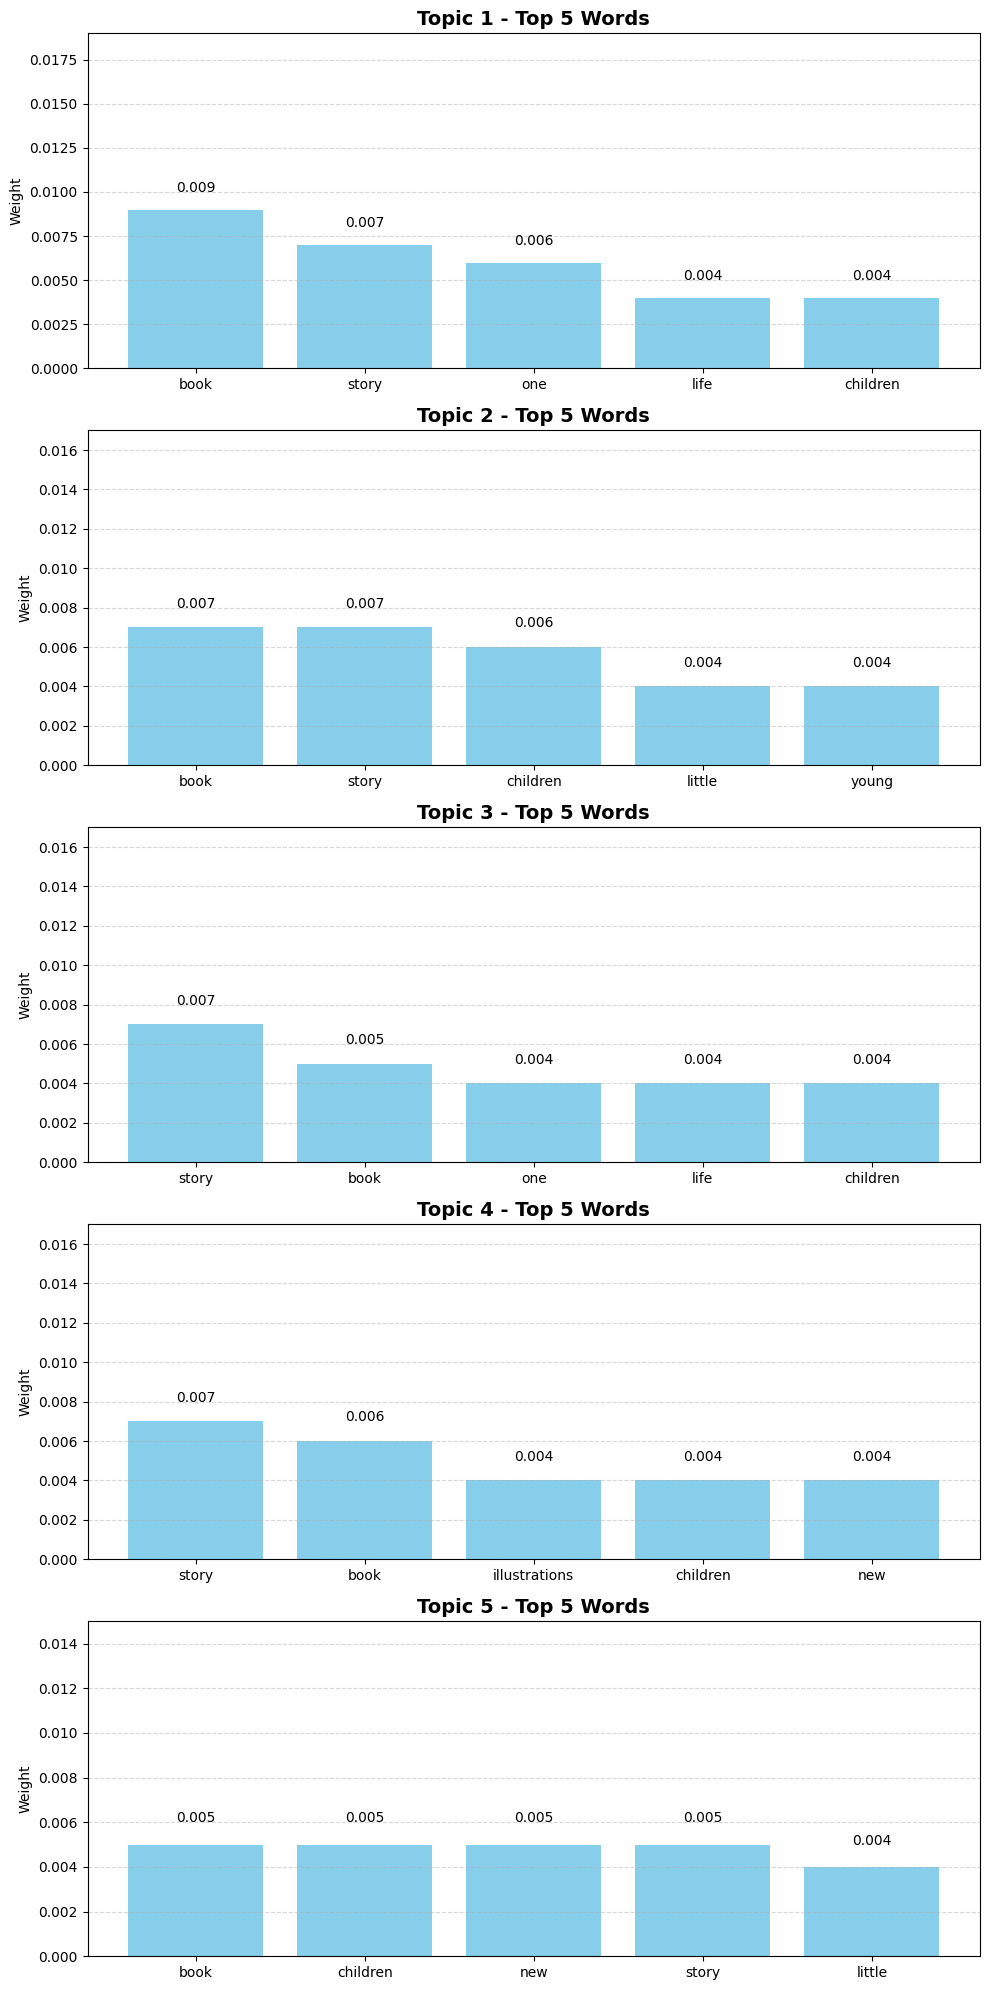

In [8]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel

# Download stopwords if not already
nltk.download('stopwords')

# 1️⃣ Preprocessing function
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep letters & spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

# 2️⃣ Apply preprocessing
df['Tokens'] = df['Description'].apply(preprocess)

# 3️⃣ Create dictionary & corpus
dictionary = corpora.Dictionary(df['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in df['Tokens']]

# 4️⃣ Train LDA model
num_topics = 5  # change if you want more/fewer topics
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=15)

# 5️⃣ Extract top 5 words per topic
topics_data = []
for topic_id, topic_words in lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
    words = [w for w, _ in topic_words]
    weights = [round(wt, 3) for _, wt in topic_words]
    topics_data.append((topic_id, words, weights))

# 6️⃣ Plotting
fig, axes = plt.subplots(nrows=num_topics, ncols=1, figsize=(10, 4*num_topics))

if num_topics == 1:
    axes = [axes]  # make it iterable if only 1 topic

for ax, (topic_id, words, weights) in zip(axes, topics_data):
    ax.bar(words, weights, color='skyblue')
    ax.set_title(f"Topic {topic_id+1} - Top 5 Words", fontsize=14, weight='bold')
    ax.set_ylabel('Weight')
    ax.set_ylim(0, max(weights)+0.01)
    for i, v in enumerate(weights):
        ax.text(i, v + 0.001, str(v), ha='center', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [1]:
# --- 🔹 Import Required Libraries ---
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt

# --- 🔹 Download NLTK Stopwords ---
nltk.download('stopwords')

# --- 🔹 Load Dataset ---
# Make sure your file path matches the uploaded one
df = pd.read_excel("C:/Users/madhu/OneDrive/Desktop/childrenstories_dataset.xlsx")
print("✅ Dataset loaded successfully!")
print(df.head())

# --- 🔹 Preprocess Text ---
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Clean, tokenize, and remove stopwords from text."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # keep only letters
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

# Copy and preprocess
df_copy = df.copy()
df_copy['Tokens'] = df_copy['Description'].apply(preprocess)
df_copy['Processed_Text'] = df_copy['Tokens'].apply(lambda x: ' '.join(x) if x else '')

print("\n✅ Preprocessing complete. Sample tokens:")
print(df_copy[['Description', 'Tokens']].head())

# --- 🔹 Create Dictionary and Corpus ---
dictionary = corpora.Dictionary(df_copy['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in df_copy['Tokens']]

# --- 🔹 Train LDA Model (5 Emotions/Topics) ---
num_topics = 5
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=15,
    random_state=42
)

# --- 🔹 Display Top 5 Words per Topic ---
print("\n🔸 Top 5 Words per Topic (Emotions):")
for topic_id, topic in lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
    print(f"\nEmotion {topic_id + 1}:")
    for word, weight in topic:
        print(f"  {word} ({weight:.3f})")

# --- 🔹 Visualize Topics with pyLDAvis ---
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
vis  # Interactive output in Jupyter

# --- 🔹 Save Visualization as HTML ---
pyLDAvis.save_html(vis, 'lda_emotions_graph.html')
print("\n✅ LDA visualization saved as 'lda_emotions_graph.html'.")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Dataset loaded successfully!
                               Title  \
0                      A TRICK TRIKE   
1                ABE THE SERVICE DOG   
2                         BUBBLE FUN   
3                  CAPTAIN FANTASTIC   
4   DO YOU WONDER WHY BUGS ARE GOOD?   

                                         Description      Age  
0  Little Ross was sad. He didnÃ¢Â€Â™t have a nic...  Age 2-9  
1  Abe was a real Service Dog who dedicated his l...  Age 2-9  
2  When the last bubble popped, he was gone but a...  Age 2-9  
3  Dr. ZobÃ¢Â€Â™s  evil plans had failed once aga...  Age 2-9  
4  Those little beauties have inspired so many st...  Age 2-9  

✅ Preprocessing complete. Sample tokens:
                                         Description  \
0  Little Ross was sad. He didnÃ¢Â€Â™t have a nic...   
1  Abe was a real Service Dog who dedicated his l...   
2  When the last bubble popped, he was gone but a...   
3  Dr. ZobÃ¢Â€Â™s  evil plans had failed once aga...   
4  Those little beauti